In [18]:
%load_ext autoreload
%autoreload 2
from trade.datamanager import (
    DividendDataManager,
    SpotDataManager,
    OptionSpotDataManager,
    VolDataManager,
    RatesDataManager,
    BaseDataManager,
    ForwardDataManager,
    GreekDataManager,
    assert_synchronized_model,
    get_option_theoretical_price,
    calculate_scenarios
)

from trade.datamanager._enums import OptionSpotEndpointSource, SeriesId, OptionPricingModel, VolatilityModel, RealTimeFallbackOption, GreekType, ModelPrice
from trade.optionlib.config.types import DivType
from trade.helpers.helper_types import SingletonMetaClass
from trade.datamanager.vars import get_loaded_names, get_times_series
get_loaded_names()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{('SBUX', datetime.date(2026, 2, 14))}

In [24]:
get_times_series().get_timeseries("SPY").spot

2026-02-14 18:46:54 [test] trade.datamanager.utils INFO: No missing dates within cached data range for key: SPY.
2026-02-14 18:46:54 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: SPY
2026-02-14 18:46:54 [test] trade.datamanager.utils INFO: Sanitizing data from 2017-01-03 00:00:00 to 2026-02-13 17:55:04.744763...
2026-02-14 18:46:54 [test] trade.datamanager.utils INFO: No missing dates within cached data range for key: SPY.
2026-02-14 18:46:54 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: SPY
2026-02-14 18:46:54 [test] trade.datamanager.utils INFO: Sanitizing data from 2017-01-03 00:00:00 to 2026-02-13 17:55:04.744763...
2026-02-14 18:46:54 [test] trade.datamanager.utils INFO: No missing dates within cached data range for key: SPY.
2026-02-14 18:46:54 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: SPY
2026-02-14 18:46:54 [test] trade.datamanager.utils INFO: Sanitizing data from 201

,open,high,low,close,volume,chain_price,unadjusted_close,split_ratio,cum_split,split_factor,max_cum_split,is_split_date
datetime,,,,,,,,,,,,
2017-01-03,194.825819,195.509760,193.821573,194.998978,91366500,194.998978,194.998978,1.0,1.0,1.0,1.0,False
2017-01-04,195.327912,196.306201,195.319260,196.159027,78744400,196.159027,196.159027,1.0,1.0,1.0,1.0,False
2017-01-05,195.890713,196.159090,195.206772,196.003250,78379000,196.003250,196.003250,1.0,1.0,1.0,1.0,False
2017-01-06,196.115743,197.171945,195.570324,196.704453,71559900,196.704453,196.704453,1.0,1.0,1.0,1.0,False
2017-01-09,196.444740,196.583262,196.020524,196.055161,46939700,196.055161,196.055161,1.0,1.0,1.0,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-09,689.419983,695.869995,688.340027,693.950012,73885200,693.950012,693.950012,1.0,1.0,1.0,1.0,False
2026-02-10,694.950012,696.539978,691.659973,692.119995,65185700,692.119995,692.119995,1.0,1.0,1.0,1.0,False
2026-02-11,696.390015,697.140015,689.179993,691.960022,76353900,691.960022,691.960022,1.0,1.0,1.0,1.0,False


In [ ]:
BaseDataManager.clear_all_caches()

2026-02-01 01:08:12 [test] trade.datamanager.base INFO: Clearing cache for DividendDataManager (CACHE_NAME='dividend_data_manager')
2026-02-01 01:08:12 [test] trade.datamanager.base INFO: Clearing cache for RatesDataManager (CACHE_NAME='rates_data_manager')
2026-02-01 01:08:12 [test] trade.datamanager.base INFO: Clearing cache for ForwardDataManager (CACHE_NAME='forward_data_manager')
2026-02-01 01:08:12 [test] trade.datamanager.base INFO: Clearing cache for OptionSpotDataManager (CACHE_NAME='option_spot_manager')
2026-02-01 01:08:12 [test] trade.datamanager.base INFO: Clearing cache for SpotDataManager (CACHE_NAME='spot_data_manager')
2026-02-01 01:08:12 [test] trade.datamanager.base INFO: Clearing cache for VolDataManager (CACHE_NAME='vol_data_manager_cache')
2026-02-01 01:08:12 [test] trade.datamanager.base INFO: Clearing cache for GreekDataManager (CACHE_NAME='greek_datamanager_cache')


In [2]:
SingletonMetaClass._instances.keys()

dict_keys([<class 'trade.datamanager.config.OptionDataConfig'>])

## TEST 1:

In [3]:
## Vars
div = DivType.DISCRETE
undo_adjust = True
endpoint_source = OptionSpotEndpointSource.EOD
series_id = SeriesId.HIST
market_model = OptionPricingModel.BSM
vol_model = VolatilityModel.MARKET
model_price = ModelPrice.ASK

symbol = "SBUX"
expiration = "2026-09-18"
right = "C"
strike = 100.0
ts_start = "2025-01-01"
ts_end = "2026-01-28"

In [4]:
BaseDataManager.CONFIG.dividend_type = div
BaseDataManager.CONFIG.undo_adjust = undo_adjust
BaseDataManager.CONFIG.option_spot_endpoint_source = endpoint_source
BaseDataManager.CONFIG.option_model = market_model
BaseDataManager.CONFIG.volatility_model = vol_model
BaseDataManager.CONFIG.model_price = model_price
BaseDataManager.CONFIG.assert_valid()

In [5]:
BaseDataManager.CONFIG.dividend_type


<DivType.DISCRETE: 'discrete'>

In [ ]:
div_dm = DividendDataManager(symbol=symbol) # Checked for cache consistency
spot_dm = SpotDataManager(symbol=symbol) 
option_spot_dm = OptionSpotDataManager(symbol=symbol) # Checked for cache consistency
vol_dm = VolDataManager(symbol=symbol) # Checked for cache consistency
rates_dm = RatesDataManager() # Checked for cache consistency
fwd_dm = ForwardDataManager(symbol=symbol) # Checked for cache consistency
greek_dm = GreekDataManager(symbol=symbol) # Checked for cache consistency

2026-02-14 17:55:06 [test] trade.datamanager.base INFO: dividend_data_manager has expired 5 entries
2026-02-14 17:55:07 [test] trade.datamanager.base INFO: forward_data_manager has expired 10 entries


In [17]:
div_data = fwd_dm.get_forward_timeseries(
    start_date=ts_start,
    end_date="2026-02-13",
    maturity_date=expiration,
    dividend_type=DivType.CONTINUOUS,
)
div_data.timeseries

2026-02-14 18:05:10 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-14 18:05:10 [test] trade.datamanager.utils INFO: Converting old cache data structure to new for key: symbol:SBUX|interval:eod|artifact_type:forward|series_id:hist|dividend_type:CONTINUOUS|maturity:2026-09-18|use_chain_spot:1
2026-02-14 18:05:10 [test] trade.datamanager.utils INFO: No missing dates within cached data range for key: symbol:SBUX|interval:eod|artifact_type:forward|series_id:hist|dividend_type:CONTINUOUS|maturity:2026-09-18|use_chain_spot:1.
2026-02-14 18:05:10 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: symbol:SBUX|interval:eod|artifact_type:forward|series_id:hist|dividend_type:CONTINUOUS|maturity:2026-09-18|use_chain_spot:1
2026-02-14 18:05:10 [test] trade.datamanager.utils INFO: Sanitizing data from 2025-01-02 00:00:00 to 2026-02-13 00:00:00...
2026-02-14 18:05:10 [test] trade.datamanager.forward INFO: Cache hit for forward timeseries 

datetime
2025-01-02     94.751092
2025-01-03     95.143947
2025-01-06     95.683210
2025-01-07     95.393685
2025-01-08     95.138279
                 ...    
2026-02-09    100.125799
2026-02-10     98.643647
2026-02-11    100.255887
2026-02-12     97.850734
2026-02-13     95.439190
Name: forward, Length: 280, dtype: float64

In [8]:
div_data = div_dm.get_schedule_timeseries(
    start_date=ts_start,
    end_date=ts_end,
    maturity_date=expiration,
)

fwd_data = fwd_dm.get_forward_timeseries(
    start_date=ts_start,
    end_date=ts_end,
    maturity_date=expiration,
)

spot_data = spot_dm.get_spot_timeseries(
    start_date=ts_start,
    end_date=ts_end,
)

option_spot_data = option_spot_dm.get_option_spot_timeseries(
    expiration=expiration,
    right=right,
    strike=strike,
    start_date=ts_start,
    end_date=ts_end,
)

vol_data = vol_dm.get_implied_volatility_timeseries(
    expiration=expiration,
    right=right,
    strike=strike,
    start_date=ts_start,
    end_date=ts_end,
)

greek_data = greek_dm.get_greeks_timeseries(
    expiration=expiration,
    right=right,
    strike=strike,
    start_date=ts_start,
    end_date=ts_end,
)

2026-02-01 01:08:14 [test] trade.datamanager.vars INFO: Loading timeseries for SBUX...


2026-02-01 01:08:14 [test] EventDriven.riskmanager.market_data INFO: Timeseries for SBUX already loaded. Use force=False to reload.
2026-02-01 01:08:14 [test] trade.datamanager.dividend INFO: Using config default dividend_type: DivType.CONTINUOUS
2026-02-01 01:08:14 [test] EventDriven.riskmanager.market_data WARNING: End date 2026-02-01 01:08:10.925009 is today or in the future and current time is before market close. Forcing preload check.
2026-02-01 01:08:15 [test] EventDriven.riskmanager.market_data INFO: Sanitizing today's data from all stored timeseries data...
2026-02-01 01:08:15 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:08:15 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:08:15 [test] trade.datamanager.dividend INFO: Using provided dividend_type: DivType.CONTINUOUS
2026-02-01 01:08:15 [test] EventDriven.riskmanager.market_data WARNING: End date 2026-02-01 01:08:10.925009 is today or in the future 

In [9]:
print(f"Dividend Type from Config: {BaseDataManager.CONFIG.dividend_type}")
print(f"Dividend Type from Dividend DataManager: {div_dm.CONFIG.dividend_type}")
print(f"Dividend Type from Dividend Data: {div_data.dividend_type}")
print("\n")
print(f"Dividend Type from ForwardDataManager: {fwd_dm.CONFIG.dividend_type}")
print(f"Dividend Type from Forward Data: {fwd_data.dividend_type}")
print("\n")
print(f"Dividend Type from SpotDataManager: {spot_dm.CONFIG.dividend_type}")
print("\n")
print(f"Dividend Type from OptionSpotDataManager: {option_spot_dm.CONFIG.dividend_type}")
print("\n")
print(f"Dividend Type from VolDataManager: {vol_dm.CONFIG.dividend_type}")
print(f"Dividend Type from Vol Data: {vol_data.dividend_type}")
print("\n")
print(f"Dividend Type from GreekDataManager: {greek_dm.CONFIG.dividend_type}")
print(f"Dividend Type from Greek Data: {greek_data.dividend_type}")
# div_data.dividend_type


Dividend Type from Config: DivType.CONTINUOUS
Dividend Type from Dividend DataManager: DivType.CONTINUOUS
Dividend Type from Dividend Data: DivType.CONTINUOUS


Dividend Type from ForwardDataManager: DivType.CONTINUOUS
Dividend Type from Forward Data: DivType.CONTINUOUS


Dividend Type from SpotDataManager: DivType.CONTINUOUS


Dividend Type from OptionSpotDataManager: DivType.CONTINUOUS


Dividend Type from VolDataManager: DivType.CONTINUOUS
Dividend Type from Vol Data: DivType.CONTINUOUS


Dividend Type from GreekDataManager: DivType.CONTINUOUS
Dividend Type from Greek Data: DivType.CONTINUOUS


In [10]:
assert_synchronized_model(
    symbol=symbol,
    undo_adjust=undo_adjust,
    dividend_type=div,
    spot = spot_data,
    dividend = div_data,
    forward = fwd_data,
    option_spot = option_spot_data,
    vol = vol_data,
    greek=greek_data,
    model_price=model_price)
    

<Axes: xlabel='datetime'>

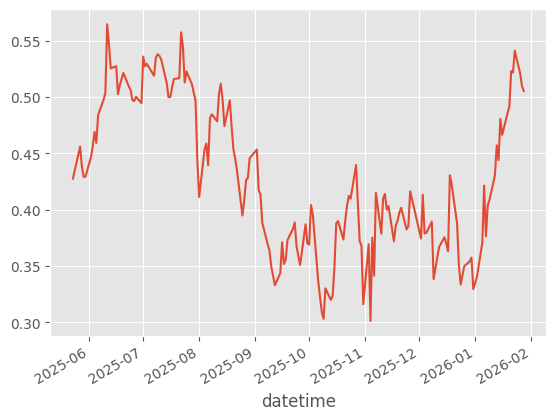

In [11]:
greek_data.delta.plot()

In [12]:
greek_dm.rt(
    expiration=expiration,
    right=right,
    strike=strike,
).timeseries

2026-02-01 01:08:26 [test] trade.datamanager.utils WARNING: Valuation date 2026-02-01 01:08:26.642208 is not a business day or holiday. Resolving using fallback options RealTimeFallbackOption.USE_LAST_AVAILABLE.
2026-02-01 01:08:26 [test] trade.datamanager.utils INFO: Using last available business day for valuation date.
2026-02-01 01:08:26 [test] trade.datamanager.utils INFO: New valuation date: 2026-01-30 01:08:26
2026-02-01 01:08:26 [test] trade.datamanager.utils INFO: Using cached date range for 2026-01-30 01:08:26 - 2026-01-30 01:08:26 and option tick SBUX20260918C100
2026-02-01 01:08:26 [test] trade.datamanager.utils INFO: No cache found for key: symbol:SBUX|interval:eod|artifact_type:greeks|series_id:hist|dividend_type:continuous|endpoint_source:quote|expiration:2026-09-18|model_price:ask|option_pricing_model:Black-Scholes|right:C|strike:100|volatility_model:market. Fetching from source.
2026-02-01 01:08:26 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.


,gamma,volga,rho,delta,theta,vega
datetime,,,,,,
2026-01-30,0.017735,0.000566,0.214852,0.437738,-0.022127,0.287246


In [13]:
vol_dm.rt(
    expiration=expiration,
    right=right,
    strike=strike,
).timeseries

2026-02-01 01:08:30 [test] trade.datamanager.vol WARNING: Valuation date 2026-02-01 00:00:00 is not a business day or holiday. Resolving using fallback options RealTimeFallbackOption.USE_LAST_AVAILABLE.
2026-02-01 01:08:30 [test] trade.datamanager.vol INFO: VolDm Using specified dividend type: DivType.DISCRETE
2026-02-01 01:08:30 [test] trade.datamanager.vol INFO: VolDm Using model price: ModelPrice.ASK
2026-02-01 01:08:30 [test] trade.datamanager.utils INFO: Using cached date range for 2026-01-30 00:00:00 - 2026-01-30 00:00:00 and option tick SBUX20260918C100
2026-02-01 01:08:30 [test] trade.datamanager.utils INFO: No cache found for key: symbol:SBUX|interval:eod|artifact_type:iv|series_id:hist|dividend_type:discrete|endpoint_source:quote|expiration:2026-09-18|model_price:ask|option_pricing_model:Black-Scholes|right:C|strike:100|volatility_model:market. Fetching from source.
2026-02-01 01:08:30 [test] trade.datamanager.rates INFO: Cache hit for risk-free rate timeseries key: symbol:^I

datetime
2026-01-30    0.324693
dtype: float64

<Axes: xlabel='datetime'>

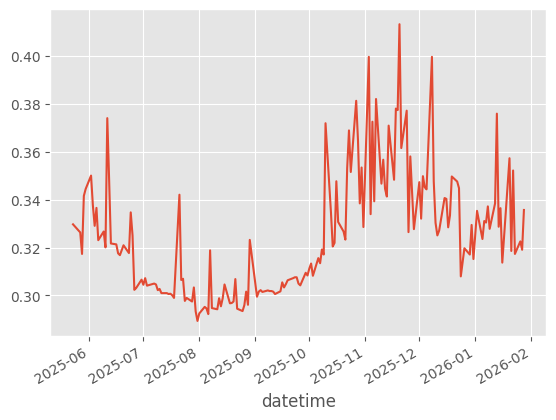

In [14]:
vol_data.timeseries.plot()

## TEST 2:

In [15]:
## Vars
div = DivType.DISCRETE
undo_adjust = True
endpoint_source = OptionSpotEndpointSource.QUOTE
series_id = SeriesId.HIST
market_model = OptionPricingModel.BINOMIAL
vol_model = VolatilityModel.MARKET

# symbol = "AMD"
# expiration = "2027-12-17"
# right = "P"
# strike = 210.0
# ts_start = "2025-01-01"
# ts_end = "2026-01-23"

In [16]:
BaseDataManager.CONFIG.dividend_type = div
BaseDataManager.CONFIG.undo_adjust = undo_adjust
BaseDataManager.CONFIG.option_spot_endpoint_source = endpoint_source
BaseDataManager.CONFIG.option_model = market_model
BaseDataManager.CONFIG.volatility_model = vol_model
BaseDataManager.CONFIG.assert_valid()

In [17]:
BaseDataManager.CONFIG.dividend_type


<DivType.DISCRETE: 'discrete'>

In [18]:
div_dm = DividendDataManager(symbol=symbol)
spot_dm = SpotDataManager(symbol=symbol)
option_spot_dm = OptionSpotDataManager(symbol=symbol)
vol_dm = VolDataManager(symbol=symbol)
rates_dm = RatesDataManager()
fwd_dm = ForwardDataManager(symbol=symbol)
greek_dm = GreekDataManager(symbol=symbol)

In [19]:
div_data = div_dm.get_schedule_timeseries(
    start_date=ts_start,
    end_date=ts_end,
    maturity_date=expiration,
)

fwd_data = fwd_dm.get_forward_timeseries(
    start_date=ts_start,
    end_date=ts_end,
    maturity_date=expiration,
)

spot_data = spot_dm.get_spot_timeseries(
    start_date=ts_start,
    end_date=ts_end,
)

option_spot_data = option_spot_dm.get_option_spot_timeseries(
    expiration=expiration,
    right=right,
    strike=strike,
    start_date=ts_start,
    end_date=ts_end,
)

vol_data = vol_dm.get_implied_volatility_timeseries(
    expiration=expiration,
    right=right,
    strike=strike,
    start_date=ts_start,
    end_date=ts_end,
)

greek_data = greek_dm.get_greeks_timeseries(
    expiration=expiration,
    right=right,
    strike=strike,
    start_date=ts_start,
    end_date=ts_end,
)

2026-02-01 01:08:34 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:08:34 [test] trade.datamanager.dividend INFO: Using config default dividend_type: DivType.DISCRETE
2026-02-01 01:08:34 [test] trade.datamanager.dividend INFO: Fetching discrete dividend schedule timeseries for SBUX from 2025-01-01 to 2026-01-28 with maturity 2026-09-18
2026-02-01 01:08:34 [test] trade.datamanager.dividend INFO: Cache hit for discrete schedule timeseries key: symbol:SBUX|interval:eod|artifact_type:divs|series_id:hist|current_state:SCHEDULE_TIMESERIES|lookback_years:1|maturity:2026-09-18|method:CONSTANT|undo_adjust:1
2026-02-01 01:08:34 [test] trade.datamanager.dividend INFO: Cache partially covers requested date range for timeseries. Key: symbol:SBUX|interval:eod|artifact_type:divs|series_id:hist|current_state:SCHEDULE_TIMESERIES|lookback_years:1|maturity:2026-09-18|method:CONSTANT|undo_adjust:1. Fetching missing dates: [Timestamp('2025-01-02 00:00:00'), Timestamp('

2026-02-01 01:08:34 [test] trade.datamanager.utils INFO: Sanitizing data from 2025-01-01 to 2026-01-28...
2026-02-01 01:08:34 [test] trade.datamanager.utils INFO: Cutting off today's data for key: symbol:SBUX|interval:eod|artifact_type:divs|series_id:hist|current_state:SCHEDULE_TIMESERIES|lookback_years:1|maturity:2026-09-18|method:CONSTANT|undo_adjust:1 to avoid saving partial day data.
2026-02-01 01:08:34 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:08:34 [test] trade.datamanager.forward INFO: Cache partially covers requested date range for forward timeseries. Key: symbol:SBUX|interval:eod|artifact_type:forward|series_id:hist|dividend_type:DISCRETE|maturity:2026-09-18|use_chain_spot:1. Fetching missing dates: [Timestamp('2025-01-02 00:00:00'), Timestamp('2025-01-03 00:00:00'), Timestamp('2025-01-06 00:00:00'), Timestamp('2025-01-07 00:00:00'), Timestamp('2025-01-08 00:00:00'), Timestamp('2025-01-10 00:00:00'), Timestamp('2025-01-13 00:00:00'),

In [1]:
greek_data.__dict__.keys()

NameError: name 'greek_data' is not defined

<Axes: xlabel='datetime'>

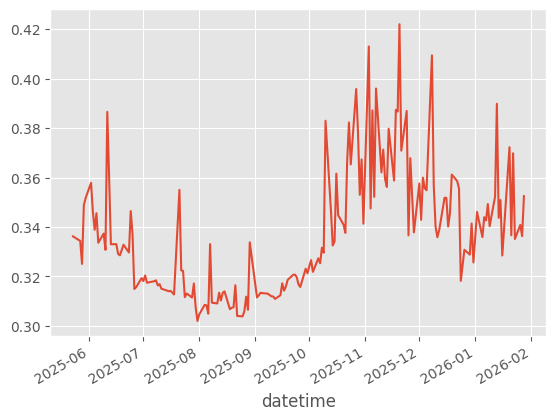

In [21]:
vol_data.timeseries.plot()

In [22]:
print(f"Dividend Type from Config: {BaseDataManager.CONFIG.dividend_type}")
print(f"Dividend Type from Dividend DataManager: {div_dm.CONFIG.dividend_type}")
print(f"Dividend Type from Dividend Data: {div_data.dividend_type}")
print("\n")
print(f"Dividend Type from ForwardDataManager: {fwd_dm.CONFIG.dividend_type}")
print(f"Dividend Type from Forward Data: {fwd_data.dividend_type}")
print("\n")
print(f"Dividend Type from SpotDataManager: {spot_dm.CONFIG.dividend_type}")
print("\n")
print(f"Dividend Type from OptionSpotDataManager: {option_spot_dm.CONFIG.dividend_type}")
print("\n")
print(f"Dividend Type from VolDataManager: {vol_dm.CONFIG.dividend_type}")
print(f"Dividend Type from Vol Data: {vol_data.dividend_type}")
# div_data.dividend_type


Dividend Type from Config: DivType.DISCRETE
Dividend Type from Dividend DataManager: DivType.DISCRETE
Dividend Type from Dividend Data: DivType.DISCRETE


Dividend Type from ForwardDataManager: DivType.DISCRETE
Dividend Type from Forward Data: DivType.DISCRETE


Dividend Type from SpotDataManager: DivType.DISCRETE


Dividend Type from OptionSpotDataManager: DivType.DISCRETE


Dividend Type from VolDataManager: DivType.DISCRETE
Dividend Type from Vol Data: DivType.DISCRETE


In [23]:
assert_synchronized_model(
    symbol=symbol,
    undo_adjust=undo_adjust,
    dividend_type=div,
    spot = spot_data,
    dividend = div_data,
    forward = fwd_data,
    option_spot = option_spot_data,
    vol = vol_data,
    greek= greek_data,
    market_model=market_model,
    vol_model=vol_model,
    require_anchor=True)

In [24]:
vol_data.timeseries#.plot()

datetime
2025-05-23    0.336226
2025-05-27    0.334374
2025-05-28    0.325076
2025-05-29    0.348844
2025-05-30    0.351742
                ...   
2026-01-22    0.369853
2026-01-23    0.335153
2026-01-26    0.340872
2026-01-27    0.336315
2026-01-28    0.352491
Length: 171, dtype: float64

## TEST 3: Load all

In [25]:
from trade.datamanager.utils.model import LoadRequest, _load_model_data_timeseries
from trade.helpers.decorators import cProfiler
from trade.helpers.helper import print_top_cprofile_stats, print_cprofile_internal_time_share

request = LoadRequest(
    symbol=symbol,
    start_date=ts_start,
    end_date=ts_end,
    expiration=expiration,
    strike=strike,
    right=right,
    series_id=SeriesId.HIST,
    dividend_type=DivType.CONTINUOUS,
    endpoint_source=OptionSpotEndpointSource.EOD,
    vol_model=VolatilityModel.MARKET,
    market_model=OptionPricingModel.BINOMIAL,
    model_price=ModelPrice.ASK,
    load_spot=True,
    load_dividend=True,
    load_forward=True,
    load_option_spot=True,
    load_vol=True,
    load_greek=True,
    undo_adjust=True,
)

f = cProfiler(_load_model_data_timeseries)
res, stats = f(request)

2026-02-01 01:09:12 [test] trade.datamanager.base INFO: Clearing cache for DividendDataManager (CACHE_NAME='dividend_data_manager')
2026-02-01 01:09:12 [test] trade.datamanager.base INFO: Clearing cache for RatesDataManager (CACHE_NAME='rates_data_manager')
2026-02-01 01:09:12 [test] trade.datamanager.base INFO: Clearing cache for ForwardDataManager (CACHE_NAME='forward_data_manager')
2026-02-01 01:09:12 [test] trade.datamanager.base INFO: Clearing cache for OptionSpotDataManager (CACHE_NAME='option_spot_manager')
2026-02-01 01:09:12 [test] trade.datamanager.base INFO: Clearing cache for SpotDataManager (CACHE_NAME='spot_data_manager')
2026-02-01 01:09:12 [test] trade.datamanager.base INFO: Clearing cache for VolDataManager (CACHE_NAME='vol_data_manager_cache')
2026-02-01 01:09:12 [test] trade.datamanager.base INFO: Clearing cache for GreekDataManager (CACHE_NAME='greek_datamanager_cache')
2026-02-01 01:09:12 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-

In [26]:
print_top_cprofile_stats(stats, top_n=20, full_name=True)

Function                                                                                                                         CumTime   RatioToTop
------------------------------------------------------------------------------------------------------------------------------------------------------
/Users/chiemelienwanisobi/cloned_repos/QuantTools/trade/datamanager/utils/model.py:315 _load_model_data_timeseries               53.0695         1.00
/Users/chiemelienwanisobi/cloned_repos/QuantTools/trade/datamanager/option_spot.py:213 get_option_spot_timeseries                43.3073         0.82
/Users/chiemelienwanisobi/cloned_repos/QuantTools/trade/datamanager/option_spot.py:378 _query_thetadata_api                      43.1941         0.81
/Users/chiemelienwanisobi/cloned_repos/FinanceDatabase/dbase/DataAPI/ThetaData/v2.py:414 request_from_proxy                      42.6873         0.80
/Users/chiemelienwanisobi/miniconda3/envs/openbb_new_use/lib/python3.11/site-packages/requests/api.

In [28]:
res.time_to_load

{'date_range_packet': 0.0004010200500488281,
 'dividend_load_time': 0.6139051914215088,
 'spot_load_time': 0.31241703033447266,
 'forward_load_time': 4.112335920333862,
 'option_spot_load_time': 5.0142059326171875,
 'vol_load_time': 0.9962790012359619,
 'greek_load_time': 41.98507881164551}

## Scenarios Calc

In [49]:
bsm = calculate_scenarios(
    symbol=symbol,
    expiration=expiration,
    right=right,
    strike=strike,
    as_of=ts_end,
    return_pnl_in_pct=True,
    return_pnl=True
)

2026-02-01 01:16:29 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:16:29 [test] trade.datamanager.dividend INFO: Using provided dividend_type: DivType.DISCRETE
2026-02-01 01:16:29 [test] trade.datamanager.dividend INFO: Fetching discrete dividend schedule timeseries for SBUX from 2026-01-28 00:00:00 to 2026-01-28 00:00:00 with maturity 2026-09-18 00:00:00
2026-02-01 01:16:29 [test] trade.datamanager.dividend INFO: Cache hit for discrete schedule timeseries key: symbol:SBUX|interval:eod|artifact_type:divs|series_id:hist|current_state:SCHEDULE_TIMESERIES|lookback_years:1|maturity:2026-09-18|method:CONSTANT|undo_adjust:1
2026-02-01 01:16:29 [test] trade.datamanager.dividend INFO: Cache fully covers requested date range for timeseries. Key: symbol:SBUX|interval:eod|artifact_type:divs|series_id:hist|current_state:SCHEDULE_TIMESERIES|lookback_years:1|maturity:2026-09-18|method:CONSTANT|undo_adjust:1
2026-02-01 01:16:29 [test] trade.datamanager.rates INF

In [50]:
bsm.grid

,0.90,0.95,1.00,1.05,1.10
-0.02,-0.508140,-0.308790,-0.067724,0.213810,0.532924
-0.01,-0.480935,-0.277803,-0.033834,0.249403,0.568825
0.00,-0.453823,-0.246892,0.000004,0.284972,0.604732
0.01,-0.426531,-0.216053,0.033790,0.320516,0.640641
0.02,-0.396147,-0.185282,0.067529,0.356035,0.676549


In [29]:
BaseDataManager.CONFIG.real_time_fallback_option = RealTimeFallbackOption.USE_LAST_AVAILABLE
div_dm.rt(
            maturity_date=expiration,
            undo_adjust=True,
            fallback_option=None,
            dividend_type=DivType.DISCRETE
        ).daily_discrete_dividends

2026-02-01 01:10:06 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:10:06 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:10:06 [test] trade.datamanager.dividend WARNING: Valuation date 2026-02-01 01:10:06.622074 is not a business day or holiday. No dividends available. Resolution: RealTimeFallbackOption.USE_LAST_AVAILABLE
2026-02-01 01:10:06 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:10:06 [test] trade.optionlib.assets.dividend INFO: Using dual projection method for ticker SBUX
2026-02-01 01:10:06 [test] trade.optionlib.assets.dividend INFO: Expected Dividend Size before adjustment: 11, for original valuation: 3. Size from historical divs: 8
2026-02-01 01:10:06 [test] trade.optionlib.assets.dividend INFO: Expected Dividend Size to be projected: 3
2026-02-01 01:10:06 [test] trade.optionlib.assets.dividend INFO: Projected Dividend List: [0.62, 0.62, 0.62]
2026-02-01 01:

2026-01-30    ((2026-02-14, 0.62), (2026-05-14, 0.62), (2026...
dtype: object

In [30]:
fwd_dm.rt(
            maturity_date=expiration,
            dividend_type=DivType.DISCRETE,
            dividend_result=None,
        ).timeseries

2026-02-01 01:10:06 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:10:06 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:10:06 [test] trade.datamanager.forward WARNING: Valuation date 2026-02-01 01:10:06.795244 is not a business day or holiday. No dividends available. Resolution: RealTimeFallbackOption.USE_LAST_AVAILABLE
2026-02-01 01:10:06 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:10:06 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:10:06 [test] trade.datamanager.dividend INFO: Using provided dividend_type: DivType.DISCRETE
2026-02-01 01:10:06 [test] trade.datamanager.dividend INFO: Fetching discrete dividend schedule timeseries for SBUX from 2026-01-30 to 2026-01-30 with maturity 2026-09-18
2026-02-01 01:10:06 [test] trade.datamanager.dividend INFO: No cache found for discrete schedule timeseries key: symbol:SBUX|interval:eod|

datetime
2026-01-30    92.169198
dtype: float64

In [31]:
fwd_dm.rt(
            maturity_date="2026-12-21",
            dividend_type=DivType.CONTINUOUS,
            dividend_result=None,
        ).timeseries

2026-02-01 01:10:08 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:10:08 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:10:08 [test] trade.datamanager.forward WARNING: Valuation date 2026-02-01 01:10:08.153362 is not a business day or holiday. No dividends available. Resolution: RealTimeFallbackOption.USE_LAST_AVAILABLE
2026-02-01 01:10:08 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:10:08 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 01:10:08 [test] trade.datamanager.dividend INFO: Using provided dividend_type: DivType.CONTINUOUS
2026-02-01 01:10:08 [test] EventDriven.riskmanager.market_data WARNING: End date 2026-02-01 01:08:10.925009 is today or in the future and current time is before market close. Forcing preload check.
2026-02-01 01:10:08 [test] EventDriven.riskmanager.market_data INFO: Sanitizing today's data from all stored 

datetime
2026-01-30    94.353327
dtype: float64

In [32]:
option_spot_dm.rt(
    expiration=expiration,
    right=right,
    strike=strike,
).timeseries

,bid_size,bid_exchange,bid,bid_condition,ask_size,ask_exchange,ask,ask_condition,midpoint,weighted_midpoint
datetime,,,,,,,,,,
2026-01-30,684,9,5.5,50,540,4,6.3,50,5.9,5.852941


In [33]:
vol_dm.rt(
    expiration=expiration,
    right=right,
    strike=strike,
    market_model=OptionPricingModel.BINOMIAL,
    dividend_type=DivType.DISCRETE,
).timeseries

2026-02-01 01:10:09 [test] trade.datamanager.vol WARNING: Valuation date 2026-02-01 00:00:00 is not a business day or holiday. Resolving using fallback options RealTimeFallbackOption.USE_LAST_AVAILABLE.
2026-02-01 01:10:09 [test] trade.datamanager.vol INFO: VolDm Using specified dividend type: DivType.DISCRETE
2026-02-01 01:10:09 [test] trade.datamanager.vol INFO: VolDm Using model price: ModelPrice.ASK
2026-02-01 01:10:09 [test] trade.datamanager.utils INFO: Using cached date range for 2026-01-30 00:00:00 - 2026-01-30 00:00:00 and option tick SBUX20260918C100
2026-02-01 01:10:09 [test] trade.datamanager.utils INFO: No cache found for key: symbol:SBUX|interval:eod|artifact_type:iv|series_id:hist|american:1|dividend_type:discrete|endpoint_source:quote|expiration:2026-09-18|model_price:ask|n_steps:100|option_pricing_model:Binomial|right:C|strike:100|volatility_model:market. Fetching from source.
2026-02-01 01:10:09 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2

datetime
2026-01-30    0.318936
dtype: float64

In [34]:
vol_dm.rt(
    expiration=expiration,
    right=right,
    strike=strike,
    market_model=OptionPricingModel.BSM,
    dividend_type=DivType.DISCRETE,
).timeseries

2026-02-01 01:10:11 [test] trade.datamanager.vol WARNING: Valuation date 2026-02-01 00:00:00 is not a business day or holiday. Resolving using fallback options RealTimeFallbackOption.USE_LAST_AVAILABLE.
2026-02-01 01:10:11 [test] trade.datamanager.vol INFO: VolDm Using specified dividend type: DivType.DISCRETE
2026-02-01 01:10:11 [test] trade.datamanager.vol INFO: VolDm Using model price: ModelPrice.ASK
2026-02-01 01:10:11 [test] trade.datamanager.utils INFO: Using cached date range for 2026-01-30 00:00:00 - 2026-01-30 00:00:00 and option tick SBUX20260918C100
2026-02-01 01:10:11 [test] trade.datamanager.utils INFO: No cache found for key: symbol:SBUX|interval:eod|artifact_type:iv|series_id:hist|dividend_type:discrete|endpoint_source:quote|expiration:2026-09-18|model_price:ask|option_pricing_model:Black-Scholes|right:C|strike:100|volatility_model:market. Fetching from source.
2026-02-01 01:10:11 [test] trade.datamanager.rates INFO: Cache hit for risk-free rate timeseries key: symbol:^I

datetime
2026-01-30    0.324693
dtype: float64

In [35]:
from dbase.database.db_utils import set_environment_context
from algo.strategies.init_strategies.new_system import get_multi_asset_instance
from algo.positions.vars import alpaca_client
set_environment_context("long_bbands")
instance = get_multi_asset_instance("long_bbands")

2026-02-01 01:10:12 [test] algo.__init__ CRITICAL: ALGO_DIR not on main branch; skipping runtime safeguards.


Loading BokehJS ...

[get_engine] Creating engine for DB: master_config (base: master_config), PID: 62000
[get_engine] Creating engine for DB: portfolio_data_test (base: portfolio_data), PID: 62000
Fetching rates data from yfinance directly during market hours
[get_engine] Creating engine for DB: portfolio_config_long_bbands (base: portfolio_config), PID: 62000
[get_engine] Creating engine for DB: portfolio_data_long_bbands (base: portfolio_data), PID: 62000
2026-02-01 01:10:29 [test] algo.strategies._config_utils INFO: No configuration differences found for slug 'long_bbands'.
2026-02-01 01:10:31 [test] algo.strategies._config_utils INFO: No configuration differences found for slug 'long_bbands'.
2026-02-01 01:10:31 [test] algo.strategies._config_utils INFO: No configuration differences found for slug 'long_bbands'.
2026-02-01 01:10:32 [test] algo.strategies.init_strategies INFO: Loading timeseries data from 2025-03-07 to 2026-02-01 for stocks: ['AAPL', 'NVDA', 'TSLA', 'COST', 'AMZN', 'META', 'AMD', 'SBUX

In [36]:
instance.asset_strategies

{'BA': <prod_strategies.long_bbands.strat_main.LongBBandsTrend_SL at 0x1386cc550>,
 'AMD': <prod_strategies.long_bbands.strat_main.LongBBandsTrend_SL at 0x136309f90>,
 'AAPL': <prod_strategies.long_bbands.strat_main.LongBBandsTrend_SL at 0x135409cd0>,
 'AMZN': <prod_strategies.long_bbands.strat_main.LongBBandsTrend_SL at 0x13877d790>,
 'COST': <prod_strategies.long_bbands.strat_main.LongBBandsTrend_SL at 0x138833dd0>,
 'META': <prod_strategies.long_bbands.strat_main.LongBBandsTrend_SL at 0x138729dd0>,
 'NFLX': <prod_strategies.long_bbands.strat_main.LongBBandsTrend_SL at 0x13a673f90>,
 'NVDA': <prod_strategies.long_bbands.strat_main.LongBBandsTrend_SL at 0x1371a26d0>,
 'SBUX': <prod_strategies.long_bbands.strat_main.LongBBandsTrend_SL at 0x13a577e90>,
 'TSLA': <prod_strategies.long_bbands.strat_main.LongBBandsTrend_SL at 0x13a577e50>}

In [45]:
instance.get_strategy("NVDA").plot_strategy_indicators(False)